# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [5]:
# TODO
print(f"Số dòng: {df.shape[0]}, số cột: {df.shape[1]}")
print(df.columns)
df.dtypes

Số dòng: 541909, số cột: 8
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

## A.2. Missing values & Duplicate data

In [6]:
# TODO
missing=df.isnull().sum()
print("Missing values: ")
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu")
print()
print("Duplicate rows (toàn bộ): ", df.duplicated().sum())

Missing values: 
Description      1454
CustomerID     135080
dtype: int64

Duplicate rows (toàn bộ):  5268


## A.3. Invalid values

In [8]:
print("=== INVALID VALUES ===")

print("\nQuantity <= 0:")
print(df[df["Quantity"] <= 0][["InvoiceNo", "StockCode", "Quantity"]])

print("\nUnitPrice <= 0:")
print(df[df["UnitPrice"] <= 0][["InvoiceNo", "StockCode", "UnitPrice"]])

print("\nMissing Description:")
print(df[df["Description"].isna()][["InvoiceNo", "StockCode"]])

print("\nMissing CustomerID:")
print(df[df["CustomerID"].isna()][["InvoiceNo", "CustomerID"]])

=== INVALID VALUES ===

Quantity <= 0:
       InvoiceNo StockCode  Quantity
141      C536379         D        -1
154      C536383    35004C        -1
235      C536391     22556       -12
236      C536391     21984       -24
237      C536391     21983       -24
...          ...       ...       ...
540449   C581490     23144       -11
541541   C581499         M        -1
541715   C581568     21258        -5
541716   C581569     84978        -1
541717   C581569     20979        -5

[10624 rows x 3 columns]

UnitPrice <= 0:
       InvoiceNo StockCode  UnitPrice
622       536414     22139        0.0
1970      536545     21134        0.0
1971      536546     22145        0.0
1972      536547     37509        0.0
1987      536549    85226A        0.0
...          ...       ...        ...
536981    581234     72817        0.0
538504    581406    46000M        0.0
538505    581406    46000S        0.0
538554    581408     85175        0.0
538919    581422     23169        0.0

[2517 rows x 3 co

In [7]:
# TODO
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [14]:
# TODO
df=df[(df['Quantity']>0)&(df['UnitPrice']>0)]
df['Sales']=df.Quantity*df.UnitPrice
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [22]:
# TODO
for col in['Quantity','UnitPrice']:
    mean_=df[col].mean()
    medium_=df[col].median()
    mode_=df[col].mode()[0]
    print(f"{col}: Mean: {mean_:.2f}, Medium: {medium_:.2f}, Mode: {mode_:.2f}")


Quantity: Mean: 10.54, Medium: 3.00, Mode: 1.00
UnitPrice: Mean: 3.91, Medium: 2.08, Mode: 1.25


## Group 2 — Dispersion

In [24]:
# TODO
for col in['Quantity', 'UnitPrice']:
    range=df[col].max()-df[col].min()
    std_=df[col].std()
    var_=df[col].var()
    iqr=df[col].quantile(0.75)-df[col].quantile(0.25)
    cv=std_/df[col].mean()
    print(f"---{col}---")
    print(f"Range={range:.2f}, Std={std_:.2f}, Var={var_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

---Quantity---
Range=80994.00, Std=155.52, Var=24187.75, IQR=9.00, CV=14.75
---UnitPrice---
Range=13541.33, Std=35.92, Var=1289.94, IQR=2.88, CV=9.19


## Group 3 — Location and Shape

P25=1.00, P50=3.00, P75=10.00
Skewness=471.73, Kurtosis=236460.11
P25=1.25, P50=2.08, P75=4.13
Skewness=206.09, Kurtosis=62482.55


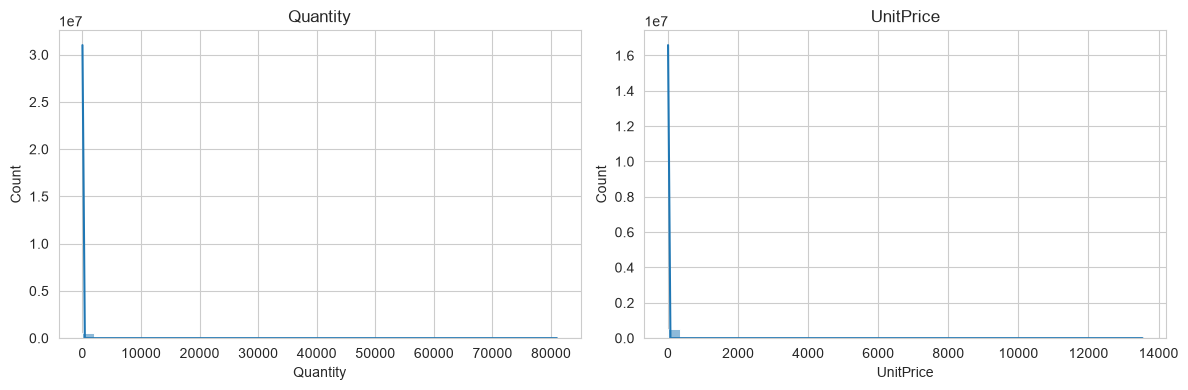

In [30]:
# TODO
for col in['Quantity', 'UnitPrice']:
    s=df[col]
    skew_ = stats.skew(s)
    kurt= stats.kurtosis(s)
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt:.2f}")
fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['Quantity'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('Quantity')
sns.histplot(df['UnitPrice'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('UnitPrice')
plt.tight_layout(); plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [31]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


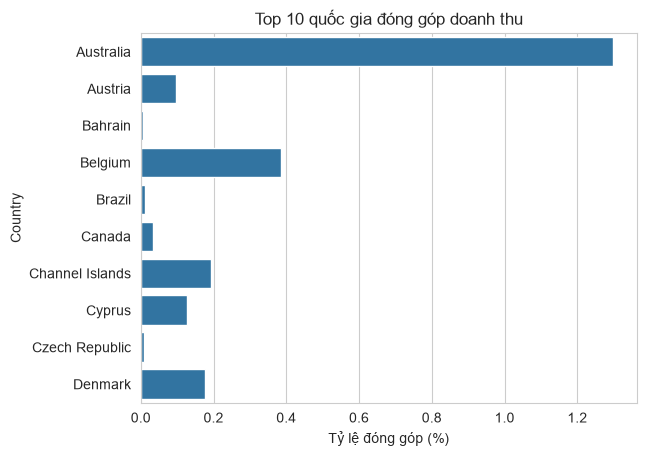

In [47]:
# TODO
tongDoanhThuQG=df.groupby('Country')['Sales'].sum()
tyLeDongGop=tongDoanhThuQG/tongDoanhThuQG.sum()*100
tyLeDongGop.sort_values(ascending=False)
tyLeDongGop=tyLeDongGop.reset_index()
tyLeDongGop.columns=['Country', 'tyLeDongGop']
top10=tyLeDongGop.head(10)
sns.barplot(data=top10, x='tyLeDongGop', y='Country')
plt.xlabel('Tỷ lệ đóng góp (%)')
plt.ylabel('Country')
plt.title('Top 10 quốc gia đóng góp doanh thu')
plt.show()


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [48]:
# TODO
doanhThuSP = df.groupby('Description')['Sales'].sum()
sanPhamTop = doanhThuSP.index[0]
doanhThuTop = doanhThuSP.iloc[0]

print(f"Sản phẩm bán chạy nhất: {sanPhamTop}")
print(f"Doanh thu: {doanhThuTop:,.2f}")

Sản phẩm bán chạy nhất:  4 PURPLE FLOCK DINNER CANDLES
Doanh thu: 290.80


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

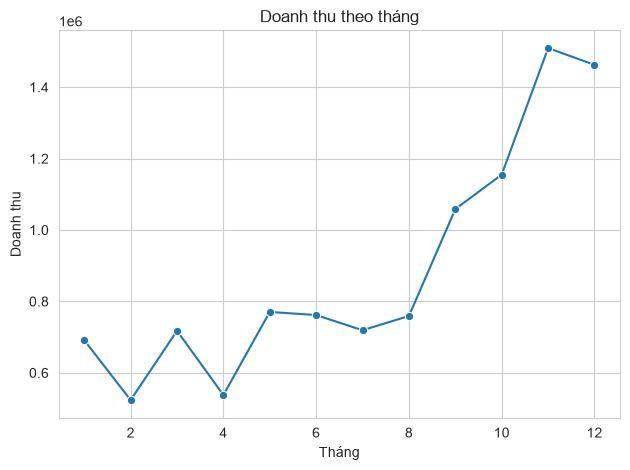

In [50]:
# TODO
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.month

doanhThuThang = df.groupby('Month')['Sales'].sum().reset_index()

sns.lineplot(
    data=doanhThuThang,
    x='Month',
    y='Sales',
    marker='o'
)

plt.xlabel('Tháng')
plt.ylabel('Doanh thu')
plt.title('Doanh thu theo tháng')
plt.tight_layout()
plt.show()

Doanh thu có dấu hiệu tính mùa vụ theo tháng. Doanh thu tương đối thấp và dao động trong giai đoạn tháng 1–8, sau đó tăng mạnh từ tháng 9 và đạt đỉnh vào tháng 11. Tháng 12 giảm nhẹ nhưng vẫn duy trì ở mức cao. Điều này cho thấy doanh thu có xu hướng tập trung vào giai đoạn cuối năm.

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

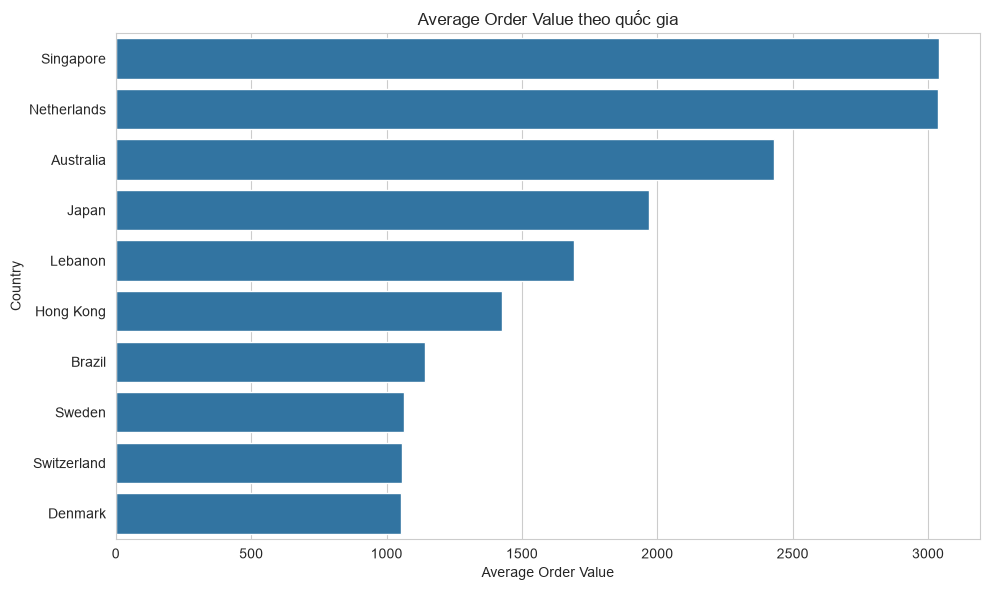

In [51]:
# TODO
order_value = df.groupby(['Country', 'InvoiceNo'])['Sales'].sum().reset_index()

aov_qg = order_value.groupby('Country')['Sales'].mean().reset_index()

aov_qg = aov_qg.sort_values('Sales', ascending=False)

top10 = aov_qg.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x='Sales',
    y='Country'
)

plt.xlabel('Average Order Value')
plt.ylabel('Country')
plt.title('Average Order Value theo quốc gia')
plt.tight_layout()
plt.show()

Giá trị đơn hàng trung bình có sự khác biệt giữa các quốc gia. Một số quốc gia có AOV cao hơn đáng kể, cho thấy khách hàng tại các quốc gia này có xu hướng chi tiêu nhiều hơn trong mỗi đơn hàng. Ngược lại, các quốc gia có AOV thấp có giá trị mua hàng trung bình nhỏ hơn.

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [53]:
# TODO
tyLeTraHang = (
    df.groupby('Country')['Quantity']
      .mean()
      .mul(100)
      .reset_index(name='ReturnRate')
      .sort_values('ReturnRate', ascending=False)
)

print(tyLeTraHang)

                 Country   ReturnRate
24           Netherlands  8493.471810
20                 Japan  8104.672897
32                Sweden  8000.665188
0              Australia  7098.223350
8         Czech Republic  2684.000000
30             Singapore  2360.810811
9                Denmark  2167.105263
10                  EIRE  1865.310520
22             Lithuania  1862.857143
5                 Canada  1829.801325
25                Norway  1805.415500
2                Bahrain  1744.444444
16             Hong Kong  1680.633803
12               Finland  1562.627737
33           Switzerland  1557.934893
18                Israel  1494.576271
35  United Arab Emirates  1444.117647
34                   USA  1373.184358
17               Iceland  1350.549451
13                France  1333.448317
14               Germany  1319.258850
6        Channel Islands  1268.850267
1                Austria  1226.381910
3                Belgium  1144.116199
31                 Spain  1124.798712
26          

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*